# 07 · A transformer challenger: NILMFormer vs Seq2Point

**Requirement 3, extended.** Seq2Point is a 2018 convolutional design. Before standing behind it,
I tested it against the strongest recent transformer I could reproduce faithfully, under the
same data, homes, masks and metrics.

| | |
|---|---|
| **Input** | the same cleaned 1-minute corpus and split as notebooks 03–06; Seq2Point checkpoints `m2_seq2point_w81_s*` |
| **Output** | checkpoints `artifacts/models/m5_nilmformer_l129_s*`, `artifacts/tables/nb07_*.csv`, `artifacts/metrics/nb07_summary.json`, figures `nb07_*` |
| **Run time** | about 30 minutes on one laptop GPU |

**Why NILMFormer.** NILMFormer (Petralia et al., KDD 2025) was designed for the problem that hurts
this project most: household load is non-stationary, so a model trained on some homes sees
different load levels in others. It standardises every window and feeds the window's mean and
spread back as a separate token, so the output scale is relearned per window. It also gets the
time of day, day of week and month as inputs. It is the only transformer I found with public code
(Apache-2.0) and published 1-minute REFIT washing-machine results. Those results use different
homes and splits, so they are not comparable with mine. It is also small: about 0.38 M
parameters against 4.2 M for Seq2Point at an 81-minute window.

**Recipe.** I follow the published recipe and declare every deviation:

| | published | here |
|---|---|---|
| architecture | 3 encoder layers, d = 96, 8 heads, dilated-conv embedding, stats token | same (port in `src/refit_nilm/models/nilmformer.py`, equivalence of the attention pinned by a test) |
| window | 128 / 256 / 512 minutes (128 best in the paper) | 129 (odd, so a window has a centre minute) |
| inputs | load + sin/cos of minute, hour, day of week, month | same, in UK local time |
| scaling | load and target divided by the largest training load | same |
| training | Adam 1e-4, batch 64, ≤ 50 epochs, early stop 10, LR on plateau 5, MSE | same; masked MSE so unusable minutes (`Issues`, outages) carry no loss, as for Seq2Point |
| inference | non-overlapping windows | each minute predicted by the window centred on it, exactly as Seq2Point is scored |

**Decision rule.** It is the acceptance rule I applied to every earlier variant (notebook 05b).
I wrote it after a 2-epoch timing check of the training code, and committed it (95895c9) after a
1-epoch end-to-end check of this notebook. Both checks were there only to catch code errors and
measure run time, and the rule did not change after them:

1. Single models, three seeds each (42, 10, 20), are compared on the validation home (House 18),
   on the minutes that both models can score.
2. The metrics are NDE and cycle F1, the two that selected the current model.
3. NILMFormer replaces Seq2Point only if its mean is better on **both** metrics by more than the
   larger of the two models' seed standard deviations. Otherwise Seq2Point stays: it is already
   validated, exported and served, and the challenger must clearly earn a change.
4. The test homes are then scored once for both three-seed ensembles, whatever the decision. This
   is the second time those homes are scored (the first was notebook 06), so I report the numbers
   and change nothing after seeing them.

**Added after the first run, without changing the rule above.** The first run's NILMFormer seeds
scored worse than predicting zero on the validation home. I stopped it and checked the port first.
`scripts/check_nilmformer_port.py` loads the original repository's code at the pinned commit and
the port with identical weights; their outputs agree to within 10⁻⁸. I then added two sections that
use no test data. Section 4 diagnoses the failure: does the model fit its own training homes?
Section 5 is one declared exploratory run with a larger training budget, scored on validation
only. Neither can change the decision: a variant chosen after seeing results would need its own
pre-registered confirmation.


In [1]:
MAX_EPOCHS = 50  # the published budget; a quick end-to-end check of this notebook sets 1
MAX_EPOCHS_EXPLORE = 15  # section 5

In [2]:
import json
import time
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

from refit_nilm import config as C
from refit_nilm import datasets as D
from refit_nilm import metrics, plots
from refit_nilm import train as T
from refit_nilm import train_seq2seq as S

warnings.filterwarnings("ignore", category=FutureWarning)
plots.setup()
pd.set_option("display.width", 160, "display.max_columns", 30)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
W_S2P, W_NF = 81, 129
SEEDS = [42, 10, 20]
frames, corpora, stats = D.prepare([W_S2P, W_NF])
cp81, cp129, st81 = corpora[W_S2P], corpora[W_NF], stats[W_S2P]
SUMMARY: dict = {"window_seq2point": W_S2P, "window_nilmformer": W_NF, "seeds": SEEDS}
print({w: {k: len(v) for k, v in c.starts.items()} for w, c in corpora.items()})

{81: {'train': 3759548, 'seen_test': 871885, 'val': 553394, 'test': 3979448}, 129: {'train': 3756834, 'seen_test': 871023, 'val': 551963, 'test': 3979158}}


## 1. The two models side by side

Parameter counts and the scaling constant. The training split is identical for both: the same
homes and the same first 80 % of each, so only the window length and the model differ.

In [3]:
s2p = T.build("seq2point", W_S2P)
nf = S.build(S.Seq2SeqConfig())
n_s2p, n_nf = (sum(p.numel() for p in m.parameters()) for m in (s2p, nf))
scale = S.training_scale(cp129)
SUMMARY["parameters"] = {"seq2point": n_s2p, "nilmformer": n_nf}
SUMMARY["nilmformer_scale_w"] = scale
pd.DataFrame({"parameters": [n_s2p, n_nf], "window (min)": [W_S2P, W_NF], "output": ["centre minute", "every minute of the window"]},
             index=["Seq2Point", "NILMFormer"])

,parameters,window (min),output
Seq2Point,4186649,81,centre minute
NILMFormer,383283,129,every minute of the window


## 2. Training NILMFormer, three seeds

Each epoch draws as many random training windows as would tile the training minutes once (about
29,000 windows, 455 steps of 64). Early stopping watches validation NDE, as for Seq2Point.

In [4]:
histories = {}
for seed in SEEDS:
    cfg = S.Seq2SeqConfig(window=W_NF, seed=seed, max_epochs=MAX_EPOCHS)
    t0 = time.time()
    model, hist, sc = S.fit(cp129, cfg, device=DEVICE)
    S.save_run(C.MODEL_DIR / f"m5_nilmformer_l{W_NF}_s{seed}.pt", model, cfg, sc, hist)
    histories[seed] = hist
    best = min(hist, key=lambda h: h["val_nde"])
    print(f"seed {seed}: {len(hist)} epochs, best epoch {best['epoch']} (val NDE {best['val_nde']:.3f}), {time.time() - t0:.0f}s")
    del model
    torch.cuda.empty_cache()
SUMMARY["nilmformer_epochs"] = {str(s): {"epochs": len(h), "best_epoch": min(h, key=lambda r: r["val_nde"])["epoch"]} for s, h in histories.items()}

epoch  1  train_loss 0.00019  val_NDE 1.1400  (19s)


epoch  2  train_loss 0.00018  val_NDE 1.2944  (18s)


epoch  3  train_loss 0.00017  val_NDE 1.1928  (19s)


epoch  4  train_loss 0.00017  val_NDE 1.1518  (20s)


epoch  5  train_loss 0.00016  val_NDE 1.1660  (20s)


...

epoch  9  train_loss 0.00013  val_NDE 1.7000  (18s)


epoch 10  train_loss 0.00013  val_NDE 1.8713  (18s)


epoch 11  train_loss 0.00013  val_NDE 1.8206  (18s)


epoch 12  train_loss 0.00013  val_NDE 2.0228  (18s)


seed 20: 12 epochs, best epoch 2 (val NDE 1.140), 222s


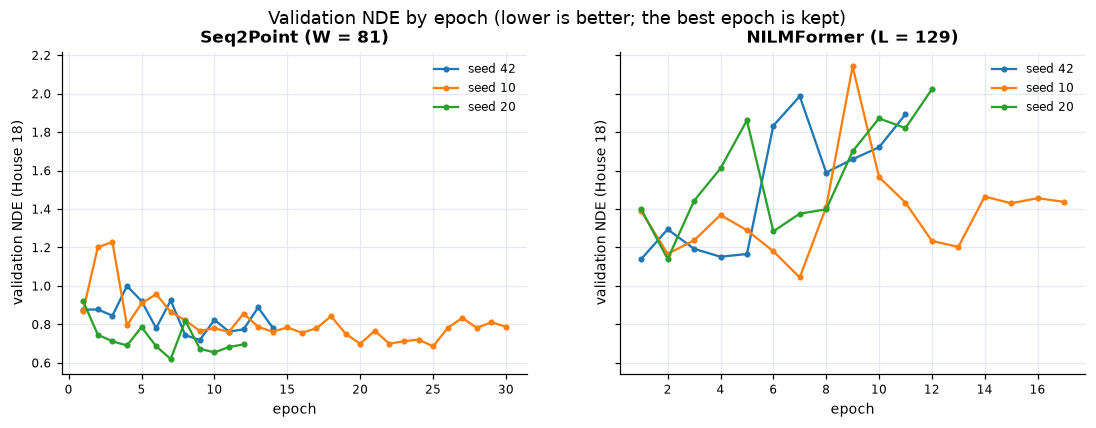

In [5]:
s2p_hist = {s: json.load(open(C.MODEL_DIR / f"m2_seq2point_w{W_S2P}_s{s}.json"))["history"] for s in SEEDS}
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8), sharey=True)
for ax, (name, hs) in zip(axes, [("Seq2Point (W = 81)", s2p_hist), ("NILMFormer (L = 129)", histories)]):
    for s, h in hs.items():
        ax.plot([r["epoch"] for r in h], [r["val_nde"] for r in h], marker="o", ms=3, label=f"seed {s}")
    ax.set(title=name, xlabel="epoch", ylabel="validation NDE (House 18)")
    ax.legend()
fig.suptitle("Validation NDE by epoch (lower is better; the best epoch is kept)")
plots.save(fig, "nb07_learning_curves")
plt.show()

## 3. Validation comparison (the decision)

Both models are scored with the project's metric code on House 18, restricted to the minutes both
can score. A minute can be valid for an 81-minute window but not for a 129-minute one near an
outage, and vice versa, so the shared set is slightly smaller than either. Seq2Point's numbers on
its own full set are in notebook 05.

In [6]:
S2P = {s: T.load_run(C.MODEL_DIR / f"m2_seq2point_w{W_S2P}_s{s}.pt", device=DEVICE)[0] for s in SEEDS}
NF = {s: S.load_run(C.MODEL_DIR / f"m5_nilmformer_l{W_NF}_s{s}.pt", device=DEVICE)[0] for s in SEEDS}
src81 = T.WindowSource(cp81, st81, DEVICE)
src129 = S.SeqWindowSource(cp129, scale, DEVICE)


def seq2point_power(cp, starts, seed):
    return T.predict(S2P[seed], src81, starts, st81)["power"]


def nilmformer_power(cp, starts, seed):
    return S.predict(NF[seed], src129, starts)


def series_for(split, house):
    # truth and per-seed predictions as minute series for one house, on the shared minutes
    st81, st129 = cp81.starts[split], cp129.starts[split]
    keep81 = cp81.house[st81 + W_S2P // 2] == house
    keep129 = cp129.house[st129 + W_NF // 2] == house
    st81, st129 = st81[keep81], st129[keep129]
    y = D.to_series(cp81, st81, cp81.wm[st81 + W_S2P // 2], house)
    preds = {}
    for s in SEEDS:
        preds[("Seq2Point", s)] = D.to_series(cp81, st81, seq2point_power(cp81, st81, s), house)
        preds[("NILMFormer", s)] = D.to_series(cp129, st129, nilmformer_power(cp129, st129, s), house)
    idx = y.index.union(preds[("NILMFormer", SEEDS[0])].index)
    y = y.reindex(idx)
    preds = {k: v.reindex(idx) for k, v in preds.items()}
    shared = y.notna() & preds[("Seq2Point", SEEDS[0])].notna() & preds[("NILMFormer", SEEDS[0])].notna()
    return y.where(shared), {k: v.where(shared) for k, v in preds.items()}


y_val, p_val = series_for("val", C.VAL_HOUSE)
SUMMARY["validation_shared_minutes"] = int(y_val.notna().sum())
rows = [{"model": m, "seed": s, **metrics.all_metrics(y_val, p)} for (m, s), p in p_val.items()]
val = pd.DataFrame(rows)
val.to_csv(C.TABLE_DIR / "nb07_validation_per_seed.csv", index=False)
cols = ["nde", "cycle_f1", "mae_w", "epd_wh", "f1", "sae", "overlap_pct", "extra_pct"]
agg = val.groupby("model")[cols].agg(["mean", "std"]).round(3)
print("shared validation minutes:", SUMMARY["validation_shared_minutes"])
agg

shared validation minutes: 551367


nde        cycle_f1          mae_w          epd_wh              f1           sae        overlap_pct        extra_pct         
             mean    std     mean    std    mean    std     mean      std   mean    std   mean    std        mean    std      mean      std
model                                                                                                                                      
NILMFormer  1.108  0.055    0.067  0.055  17.353  8.496  292.352  147.241  0.103  0.058  2.899  2.085      21.422  5.179   368.489  213.696
Seq2Point   0.675  0.051    0.603  0.016   5.296  0.548   83.813    9.026  0.426  0.033  0.590  0.091      61.286  2.568    97.719   11.602

In [7]:
m = val.groupby("model")[["nde", "cycle_f1"]].mean()
sd = val.groupby("model")[["nde", "cycle_f1"]].std()
margin = sd.max()  # the larger of the two models' seed SDs, per metric
better_nde = m.loc["NILMFormer", "nde"] < m.loc["Seq2Point", "nde"] - margin["nde"]
better_f1 = m.loc["NILMFormer", "cycle_f1"] > m.loc["Seq2Point", "cycle_f1"] + margin["cycle_f1"]
DECISION = "NILMFormer replaces Seq2Point" if (better_nde and better_f1) else "Seq2Point stays"
SUMMARY["validation"] = {
    "mean": m.round(4).to_dict(orient="index"), "sd": sd.round(4).to_dict(orient="index"),
    "margin": margin.round(4).to_dict(), "nilmformer_better_nde": bool(better_nde), "nilmformer_better_cycle_f1": bool(better_f1),
    "decision": DECISION,
}
print(f"NDE        Seq2Point {m.loc['Seq2Point','nde']:.3f}  NILMFormer {m.loc['NILMFormer','nde']:.3f}  margin {margin['nde']:.3f}  -> NILMFormer clearly better: {better_nde}")
print(f"cycle F1   Seq2Point {m.loc['Seq2Point','cycle_f1']:.3f}  NILMFormer {m.loc['NILMFormer','cycle_f1']:.3f}  margin {margin['cycle_f1']:.3f}  -> NILMFormer clearly better: {better_f1}")
print("DECISION:", DECISION)

NDE        Seq2Point 0.675  NILMFormer 1.108  margin 0.055  -> NILMFormer clearly better: False
cycle F1   Seq2Point 0.603  NILMFormer 0.067  margin 0.055  -> NILMFormer clearly better: False
DECISION: Seq2Point stays


In [8]:
# secondary view: three-seed ensembles (mean power), the form the service uses
ens_val = {name: pd.concat([p_val[(name, s)] for s in SEEDS], axis=1).mean(axis=1, skipna=False) for name in ("Seq2Point", "NILMFormer")}
ens_val_tab = pd.DataFrame({name: metrics.all_metrics(y_val, p) for name, p in ens_val.items()}).T[cols].round(3)
SUMMARY["validation_ensemble"] = ens_val_tab.to_dict(orient="index")
ens_val_tab

,nde,cycle_f1,mae_w,epd_wh,f1,sae,overlap_pct,extra_pct
Seq2Point,0.602,0.644,5.202,80.747,0.429,0.590,62.500,96.505
NILMFormer,1.061,0.064,17.330,277.128,0.094,2.899,21.728,368.183


## 4. Diagnosis: does NILMFormer fit its own training homes?

A model can fail on a new home for two different reasons. It may learn the training homes but not
transfer (a generalisation problem), or it may not learn them at all (an optimisation problem).
The NDE on a 5 % sample of training windows, on the later 20 % of the training homes (seen) and
on the validation home separates the two. I also count optimiser steps, because the published
recipe sizes an epoch by tiling the data once with batches of 64.

In [9]:
rng = np.random.default_rng(0)
diag = []
for split in ("train", "seen_test", "val"):
    a, b = cp81.starts[split], cp129.starts[split]
    if split == "train":
        a = np.sort(rng.choice(a, len(a) // 20, replace=False))
        b = np.sort(rng.choice(b, len(b) // 20, replace=False))
    for s in SEEDS:
        diag.append({"split": split, "model": "Seq2Point", "seed": s, "nde": metrics.nde(cp81.wm[a + W_S2P // 2], seq2point_power(cp81, a, s))})
        diag.append({"split": split, "model": "NILMFormer", "seed": s, "nde": metrics.nde(cp129.wm[b + W_NF // 2], nilmformer_power(cp129, b, s))})
diag = pd.DataFrame(diag)
fit_tab = diag.groupby(["model", "split"])["nde"].agg(["mean", "std"]).round(3).unstack()
steps_s2p = {s: len(h) * int(np.ceil(len(cp81.starts["train"]) / 1000)) for s, h in s2p_hist.items()}
steps_nf = {s: len(h) * int(np.ceil(np.ceil(len(cp129.starts["train"]) / W_NF) / 64)) for s, h in histories.items()}
SUMMARY["fit_diagnosis_nde_mean"] = diag.groupby(["model", "split"])["nde"].mean().round(3).unstack().to_dict(orient="index")
SUMMARY["optimiser_steps"] = {"seq2point": steps_s2p, "nilmformer": steps_nf}
print("optimiser steps run (including the epochs after the best one):")
print("  Seq2Point :", steps_s2p)
print("  NILMFormer:", steps_nf)
fit_tab

optimiser steps run (including the epochs after the best one):
  Seq2Point : {42: 52640, 10: 112800, 20: 45120}
  NILMFormer: {42: 5016, 10: 7752, 20: 5472}


mean                     std              
split      seen_test  train    val seen_test  train    val
model                                                     
NILMFormer     0.826  0.830  1.108     0.070  0.065  0.055
Seq2Point      0.623  0.259  0.675     0.016  0.061  0.051

## 5. Exploratory: the same model with Seq2Point's training budget

One declared change, chosen because section 4 points to under-training. Each epoch draws 8× as
many windows, which gives roughly the optimiser steps Seq2Point received (about 3,600 per epoch, at
most 15 epochs). Everything else is as published. One seed, scored on validation only.

In [10]:
EXPL_FACTOR = 8
cfg_x = S.Seq2SeqConfig(window=W_NF, seed=42, max_epochs=MAX_EPOCHS_EXPLORE, windows_per_epoch_factor=EXPL_FACTOR)
model_x, hist_x, _ = S.fit(cp129, cfg_x, device=DEVICE)
S.save_run(C.MODEL_DIR / f"m5x_nilmformer_l{W_NF}_x{EXPL_FACTOR}_s42.pt", model_x, cfg_x, scale, hist_x)
st129v = cp129.starts["val"]
px = D.to_series(cp129, st129v, S.predict(model_x, src129, st129v), C.VAL_HOUSE).reindex(y_val.index).where(y_val.notna())
rows_x = [
    {"model": "Seq2Point (mean of 3 seeds)", **val[val.model == "Seq2Point"][cols].mean().to_dict()},
    {"model": "NILMFormer, published budget (mean of 3 seeds)", **val[val.model == "NILMFormer"][cols].mean().to_dict()},
    {"model": f"NILMFormer, {EXPL_FACTOR}x windows per epoch (seed 42)", **{k: metrics.all_metrics(y_val, px)[k] for k in cols}},
]
b_tr = np.sort(np.random.default_rng(0).choice(cp129.starts["train"], len(cp129.starts["train"]) // 20, replace=False))
b_seen = cp129.starts["seen_test"]
fit_x = {"train": metrics.nde(cp129.wm[b_tr + W_NF // 2], S.predict(model_x, src129, b_tr)),
         "seen_test": metrics.nde(cp129.wm[b_seen + W_NF // 2], S.predict(model_x, src129, b_seen))}
best_x = min(hist_x, key=lambda h: h["val_nde"])
SUMMARY["exploratory"] = {"factor": EXPL_FACTOR, "epochs": len(hist_x), "best_epoch": best_x["epoch"],
                          "validation": {k: round(float(v), 4) for k, v in rows_x[2].items() if k != "model"},
                          "fit_nde": {k: round(v, 3) for k, v in fit_x.items()}}
print(f"exploratory run: {len(hist_x)} epochs, best epoch {best_x['epoch']}; NDE train sample {fit_x['train']:.3f}, seen homes {fit_x['seen_test']:.3f}")
pd.DataFrame(rows_x).set_index("model").round(3)

epoch  1  train_loss 0.00017  val_NDE 1.4729  (43s)


epoch  2  train_loss 0.00014  val_NDE 1.1511  (43s)


epoch  3  train_loss 0.00012  val_NDE 2.1192  (43s)


epoch  4  train_loss 0.00011  val_NDE 1.5120  (43s)


epoch  5  train_loss 0.00010  val_NDE 1.5766  (43s)


...

epoch 10  train_loss 0.00007  val_NDE 1.1891  (43s)


epoch 11  train_loss 0.00007  val_NDE 1.3019  (43s)


epoch 12  train_loss 0.00007  val_NDE 1.2427  (43s)


exploratory run: 12 epochs, best epoch 2; NDE train sample 0.784, seen homes 0.787


,nde,cycle_f1,mae_w,epd_wh,f1,sae,overlap_pct,extra_pct
model,,,,,,,,
Seq2Point (mean of 3 seeds),0.675,0.603,5.296,83.813,0.426,0.590,61.286,97.719
"NILMFormer, published budget (mean of 3 seeds)",1.108,0.067,17.353,292.352,0.103,2.899,21.422,368.489
"NILMFormer, 8x windows per epoch (seed 42)",1.151,0.131,23.847,413.218,0.058,4.616,23.599,537.963


## 6. Unseen test homes, scored once after the decision

Both three-seed ensembles on House 8 (the reference REFIT test home) and the five other unseen
homes, on the minutes both can score, for the pre-registered models only. These homes played no
part in any choice above, and the exploratory model of section 5 is not scored on them.

In [11]:
test_rows, test_series = [], {}
for h in [C.TEST_HOUSE] + C.EXTRA_UNSEEN_HOUSES:
    y_h, p_h = series_for("test", h)
    for name in ("Seq2Point", "NILMFormer"):
        ens = pd.concat([p_h[(name, s)] for s in SEEDS], axis=1).mean(axis=1, skipna=False)
        test_rows.append({"house": h, "model": name, **metrics.all_metrics(y_h, ens)})
        if h == C.TEST_HOUSE:
            test_series[name] = ens
    if h == C.TEST_HOUSE:
        test_series["truth"] = y_h
test = pd.DataFrame(test_rows)
test.to_csv(C.TABLE_DIR / "nb07_unseen_ensembles.csv", index=False)
h8 = test[test.house == C.TEST_HOUSE].set_index("model")[cols].round(3)
mean6 = test.groupby("model")[cols].mean().round(3)
SUMMARY["house8"] = h8.to_dict(orient="index")
SUMMARY["unseen_mean"] = mean6.to_dict(orient="index")
SUMMARY["unseen_cycle_f1_per_home"] = test.pivot(index="house", columns="model", values="cycle_f1").round(3).to_dict()
print("House 8"); display(h8)
print("Mean over six unseen homes"); display(mean6)
test.pivot(index="house", columns="model", values=["nde", "cycle_f1"]).round(3)

House 8


,nde,cycle_f1,mae_w,epd_wh,f1,sae,overlap_pct,extra_pct
model,,,,,,,,
Seq2Point,0.736,0.566,23.567,339.709,0.493,0.283,37.998,33.691
NILMFormer,0.905,0.170,41.143,466.054,0.184,0.011,17.014,84.068


Mean over six unseen homes


,nde,cycle_f1,mae_w,epd_wh,f1,sae,overlap_pct,extra_pct
model,,,,,,,,
NILMFormer,0.919,0.114,21.279,256.557,0.213,0.500,18.794,119.622
Seq2Point,0.826,0.482,13.096,182.213,0.507,0.312,42.330,59.295


nde             cycle_f1          
model NILMFormer Seq2Point NILMFormer Seq2Point
house                                          
1          0.956     0.860      0.059     0.169
6          0.701     0.415      0.212     0.523
8          0.905     0.736      0.170     0.566
10         0.808     0.712      0.163     0.646
19         1.243     1.405      0.008     0.736
20         0.900     0.826      0.071     0.253

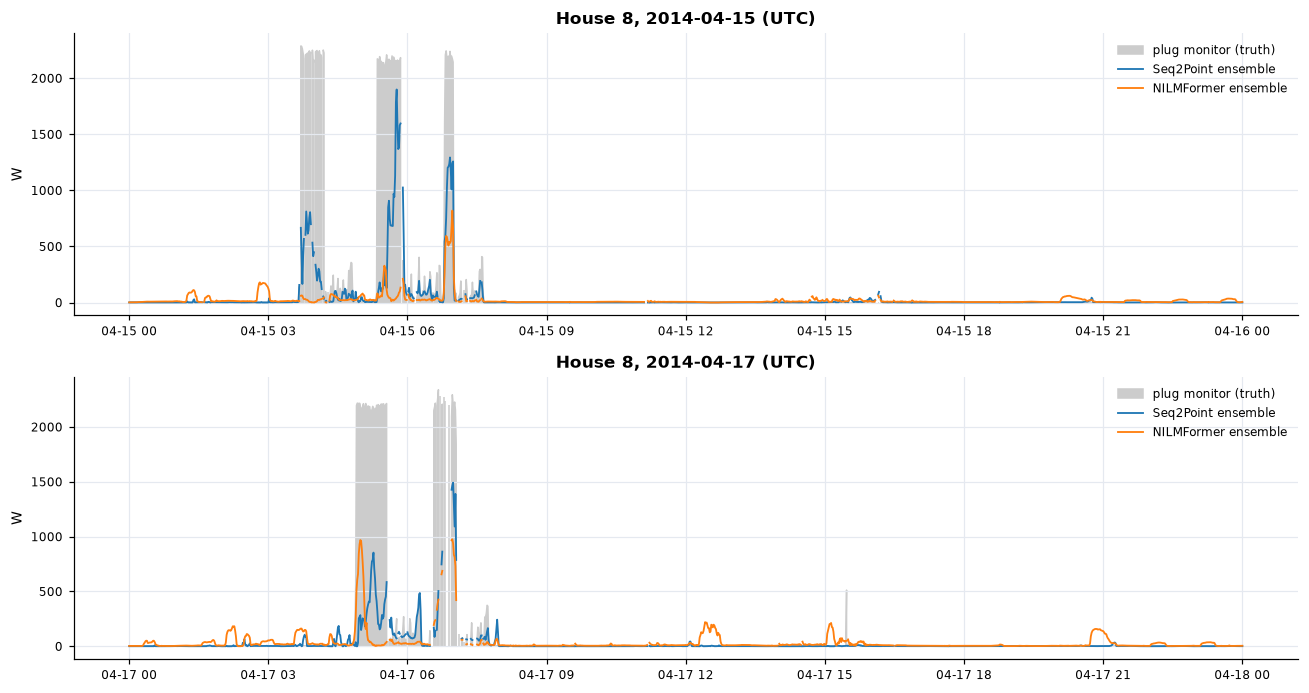

In [12]:
days = json.load(open(C.METRIC_DIR / "nb06_summary.json"))["plot_days"]
fig, axes = plt.subplots(len(days), 1, figsize=(12, 3.2 * len(days)))
for ax, day in zip(np.atleast_1d(axes), days):
    sl = slice(pd.Timestamp(day, tz="UTC"), pd.Timestamp(day, tz="UTC") + pd.Timedelta("1D"))
    ax.fill_between(test_series["truth"][sl].index, test_series["truth"][sl], color="0.8", label="plug monitor (truth)")
    ax.plot(test_series["Seq2Point"][sl], lw=1.2, label="Seq2Point ensemble")
    ax.plot(test_series["NILMFormer"][sl], lw=1.2, label="NILMFormer ensemble")
    ax.set(title=f"House 8, {day} (UTC)", ylabel="W")
    ax.legend(loc="upper right")
fig.tight_layout()
plots.save(fig, "nb07_house8_days")
plt.show()

## 7. Cost to serve

CPU time to process one day of 1-minute data (1,440 target minutes, one window each), single
thread, PyTorch eager mode, one model. This is the quantity the service pays for every request.

In [13]:
torch.set_num_threads(1)
timing = {}
for name, path, loader in [("Seq2Point", f"m2_seq2point_w{W_S2P}_s42.pt", T.load_run), ("NILMFormer", f"m5_nilmformer_l{W_NF}_s42.pt", S.load_run)]:
    model = loader(C.MODEL_DIR / path, device="cpu")[0]
    win = W_S2P if name == "Seq2Point" else W_NF
    xb = torch.randn(1440, win) if name == "Seq2Point" else torch.randn(1440, 9, win)
    with torch.no_grad():
        model(xb[:64])
        t0 = time.perf_counter()
        for i in range(0, 1440, 256):
            model(xb[i : i + 256])
        timing[name] = time.perf_counter() - t0
SUMMARY["cpu_seconds_per_day_single_model"] = {k: round(v, 3) for k, v in timing.items()}
pd.Series(timing, name="CPU s per day of data (1 thread, one model)").round(2)

Seq2Point     0.18
NILMFormer    2.85
Name: CPU s per day of data (1 thread, one model), dtype: float64

In [14]:
(C.METRIC_DIR / "nb07_summary.json").write_text(json.dumps(SUMMARY, indent=2, default=float))
print(json.dumps(SUMMARY["validation"], indent=1))

{
 "mean": {
  "NILMFormer": {
   "nde": 1.1077,
   "cycle_f1": 0.0674
  },
  "Seq2Point": {
   "nde": 0.6746,
   "cycle_f1": 0.6034
  }
 },
 "sd": {
  "NILMFormer": {
   "nde": 0.0552,
   "cycle_f1": 0.0551
  },
  "Seq2Point": {
   "nde": 0.0505,
   "cycle_f1": 0.0159
  }
 },
 "margin": {
  "nde": 0.0552,
  "cycle_f1": 0.0551
 },
 "nilmformer_better_nde": false,
 "nilmformer_better_cycle_f1": false,
 "decision": "Seq2Point stays"
}


## Summary

**Decision, by the rule stated in the header: Seq2Point stays.**

| validation home (House 18), shared minutes, mean ± sd of 3 seeds | NDE | cycle F1 | false energy (% of true) |
|---|---|---|---|
| Seq2Point | **0.675 ± 0.051** | **0.603 ± 0.016** | 98 % |
| NILMFormer, published recipe | 1.108 ± 0.055 | 0.067 ± 0.055 | 368 % |

NILMFormer is worse on both metrics, by far more than the 0.055 margin, and worse than predicting
zero on this home. The three-seed ensembles say the same: NDE 0.60 vs 1.06, cycle F1 0.64 vs 0.06.

**Why, in two layers.**
1. *Under the published budget it is under-trained.* It ran about 5,000–7,800 optimiser steps
   before early stopping, against 45,000–113,000 for Seq2Point. Its NDE on its own training homes
   is 0.83, against 0.26 for Seq2Point.
2. *Underneath, it does not transfer.* With 8× the windows per epoch (section 5), the training loss
   falls from 0.00017 to 0.00007. Validation never gets better than NDE 1.15 (epoch 2) and swings
   between 1.15 and 2.12. The published-recipe seeds show the same shape: validation error climbs
   while training error falls. So the model learns the training homes and transfers poorly.
   A plausible mechanism, which I have not tested: per-window normalisation discards the absolute
   power level, one of the few cues that separate a washing machine's 2 kW heater from other 2 kW
   loads in an unseen home. The stats token can restore that level only if what it learns
   generalises across homes.

**Unseen test homes, scored once after the decision** (three-seed ensembles, shared minutes):

| | House 8 NDE | House 8 cycle F1 | six-home mean NDE | six-home mean cycle F1 |
|---|---|---|---|---|
| Seq2Point | **0.736** | **0.566** | **0.826** | **0.482** |
| NILMFormer | 0.905 | 0.170 | 0.919 | 0.114 |

On these homes NILMFormer does better than predicting zero, unlike on House 18. It is still worse
than Seq2Point on NDE in five of six homes (better only in House 19: 1.24 vs 1.41) and on cycle F1
in all six. Its small total-energy error on House 8 (SAE 0.01) is a cancellation: it recovers only
17 % of the true energy and adds 84 % in ghost power.

**Cost to serve.** One NILMFormer model needs 2.85 s of CPU per day of data against 0.18 s for
one Seq2Point model, 16× more, because each minute needs its own 129-minute attention window.

**What this shows, and what it does not.** With this split, seven training homes and the published
recipe, NILMFormer transfers to new homes worse than Seq2Point, and a larger training budget does
not fix that. It does not show that transformers cannot work here. The comparison is worth
repeating with more training homes, cross-validation over homes for early stopping, and a tuning
budget matched to Seq2Point's.

## Verification log

* The decision rule was committed (95895c9) before the first full training run. Before that, a
  2-epoch timing check and a 1-epoch end-to-end check had run, only to catch code errors; the rule
  did not change after them. The first full
  run was stopped during its third seed, once validation NDE stayed above 1. Before changing
  anything else I checked the port against the original repository's code: identical weights give
  outputs that agree to within 10⁻⁸ (`scripts/check_nilmformer_port.py`).
* Seq2Point's numbers on the shared minutes reproduce notebook 05 (validation NDE 0.675 ± 0.051 vs
  0.68 ± 0.05) and notebook 06 (House 8 NDE 0.736 vs 0.737 on its own minute set), so the
  comparison harness is consistent with the earlier notebooks.
* Seed 42's validation curve here matches the stopped first run epoch by epoch to two decimals.
* A one-epoch end-to-end check of this notebook, run before the full run to catch errors, also
  scored the test homes. No decision depends on those numbers or on the ones above.
* Visual: on House 8 the NILMFormer ensemble catches parts of the heating blocks, at lower
  amplitude than Seq2Point, and adds 100–250 W bumps at other times of day. That matches its 84 %
  false energy.